<a href="https://colab.research.google.com/github/solankishubh24-pixel/Shubh-Solanki/blob/main/Diabetes_risk_assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 Records:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Shape:
(768, 9)

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outc

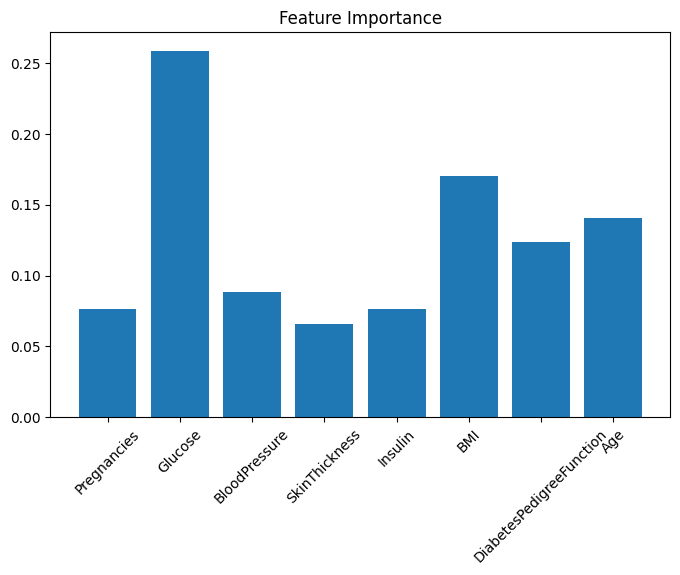


Patient Prediction:
High Risk of Diabetes


In [1]:
# ==========================================
# DIABETES RISK ASSESSMENT USING ML
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ==========================================
# LOAD DATASET
# ==========================================

url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"

df = pd.read_csv(url)

print("First 5 Records:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

# ==========================================
# CHECK MISSING VALUES
# ==========================================

print("\nMissing Values:")
print(df.isnull().sum())

# ==========================================
# FEATURES AND TARGET
# ==========================================

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# ==========================================
# TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================================
# TRAIN MODEL
# ==========================================

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# ==========================================
# PREDICT
# ==========================================

y_pred = model.predict(X_test)

# ==========================================
# EVALUATE MODEL
# ==========================================

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# ==========================================
# FEATURE IMPORTANCE
# ==========================================

importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))
plt.bar(features, importance)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

# ==========================================
# SAMPLE PATIENT PREDICTION
# ==========================================

sample_patient = pd.DataFrame({
    'Pregnancies':[2],
    'Glucose':[150],
    'BloodPressure':[85],
    'SkinThickness':[30],
    'Insulin':[130],
    'BMI':[32],
    'DiabetesPedigreeFunction':[0.5],
    'Age':[45]
})

prediction = model.predict(sample_patient)

print("\nPatient Prediction:")

if prediction[0] == 1:
    print("High Risk of Diabetes")
else:
    print("Low Risk of Diabetes")